<a href="https://colab.research.google.com/github/Shuhan78/news_index_and_predict/blob/main/stock_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 53.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 5.5 MB/s eta 0:00:00
  Created wheel for snownlp: filename=snownlp-0.12.3-py3-none-any.whl size=37760946 sha256=1c4116f5e63232326826a2082c16a8d407faff7ab050644717e92356c5ab5448
  Stored in directory: /root/.cache/pip/wheels/8a/0a/37/f15b8568f5463f1427466f701e9d3ba514035eb703f885efee
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6046 sha256=74c25cebdb388916149d5eaec89b7610a64f3838350e139f39078621dba7ba21
  Stored in directory: /root/.cache/pip/wheels/03/f5/1a/23761066dac1d0e8e683e5fdb27e12de53209d05a4a37e6246
Successfully built snownlp sgmllib3k
🔍 開始搜尋股票代號: 2308 ...


/tmp/ipykernel_1066/1953520700.py:28: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_tw = yf.download(f"{stock_id}.TW", period="1mo", progress=False)


✅ 成功獲取股價資料！
📌 股票代號: 2308
🏢 市場別: 上市 (TSE)

📰 開始嘗試透過 Google RSS 獲取【台達電】的新聞 ...
✅ 成功取得 100 則新聞


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21488 (\N{CJK UNIFIED IDEOGRAPH-53F0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 36948 (\N{CJK UNIFIED IDEOGRAPH-9054}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 38651 (\N{CJK UNIFIED IDEOGRAPH-96FB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 24066 (\N{CJK UNIFIED IDEOGRAPH-5E02}) missing from font(s) DejaVu Sans.
  fig.canvas

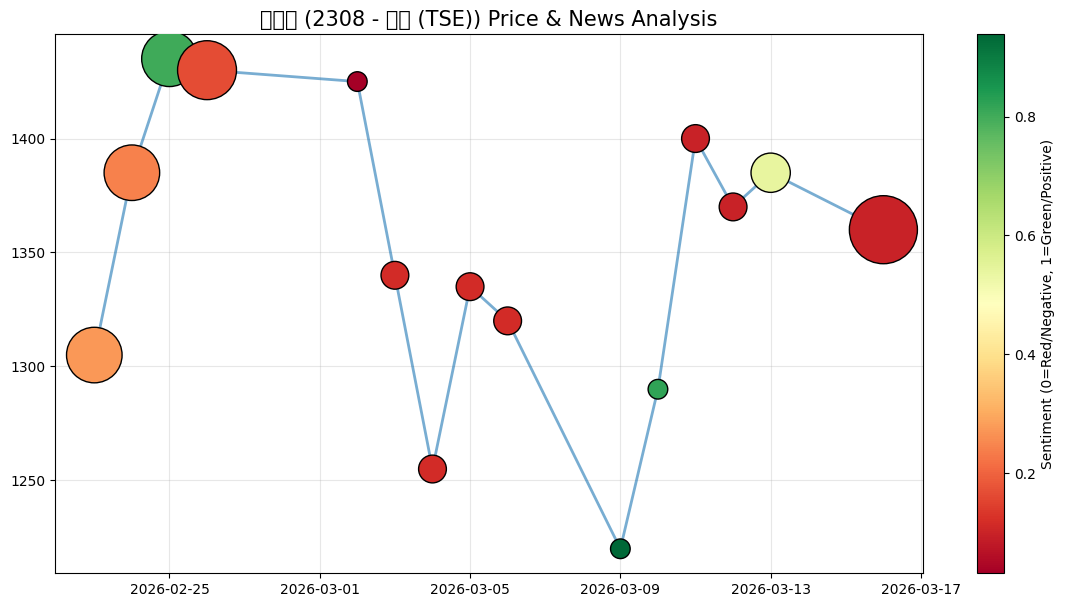


--- 📝 新聞情緒數據摘要 (前 5 筆) ---
         date                                              title  sentiment
0  2026-03-11   【Hot台股】台達電暴衝重返1400元大關！網嗨「要亮燈」 分析師曝布局時機 - Yahoo股市   0.027749
1  2026-03-16  【即時新聞】最新輝達GTC大會重磅登場！受惠AI題材台達電今日股價強勢開高 - CMoney...   0.001790
2  2026-03-13  杜金龍8點45分搶進台積電、台達電狂賺百元！旺宏、群創、鴻海可以撿？當沖秘訣曝光！看好這檔金...   0.852037
3  2026-03-13                             台達電逆勢上漲顯韌性 - cmoney.tw   0.150928
4  2026-03-16      台股震盪像洗三溫暖！杜金龍按讚台積電、台達電還看好這檔金融股衝破百元- 證券 - 工商時報   0.880407


In [3]:
!pip install yfinance snownlp feedparser

import yfinance as yf
import pandas as pd
from snownlp import SnowNLP
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import feedparser
import time
import sys

# ==========================================
# ⚙️ 1. 設定全域變數
# ==========================================
# 請輸入股票代號
stock_id = "2308"

# 請輸入搜尋新聞用的公司名稱
stock_name = "台達電"

# ==========================================
# 📈 2. 抓取股價與判定市場別(上市/上櫃/興櫃)
# ==========================================
print(f"🔍 開始搜尋股票代號: {stock_id} ...")

market_type = ""
ticker_id = ""
df_price = pd.DataFrame()

# 先測試是否為「上市 (.TW)」
df_tw = yf.download(f"{stock_id}.TW", period="1mo", progress=False)
if not df_tw.empty:
    market_type = "上市 (TSE)"
    ticker_id = f"{stock_id}.TW"
    df_price = df_tw
else:

# 若不是上市，測試是否為「上櫃 / 興櫃 (.TWO)」
    df_two = yf.download(f"{stock_id}.TWO", period="1mo", progress=False)
    if not df_two.empty:
        market_type = "上櫃 / 興櫃 "
        ticker_id = f"{stock_id}.TWO"
        df_price = df_two

# 如果都沒有資料，終止程式
if df_price.empty:
    print(f"\n❌ [錯誤] 查無此股票價格！(代號: {stock_id})")
    print("👉 可能原因：代號輸入錯誤，或該股票無近期交易紀錄。")
    sys.exit("程式已終止。")

# 查詢成功
print(f"✅ 成功獲取股價資料！")
print(f"📌 股票代號: {stock_id}")
print(f"🏢 市場別: {market_type}")

# 處理 yfinance 新版的格式問題 (清理 DataFrame)
if isinstance(df_price.columns, pd.MultiIndex):
    df_price = df_price['Close']
else:
    df_price = df_price[['Close']]
df_price.index = pd.to_datetime(df_price.index).tz_localize(None)

# ==========================================
# 📰 3. 抓取新聞 (Google RSS 自動代入 stock_name)
# ==========================================
news_list = []
print(f"\n📰 開始嘗試透過 Google RSS 獲取【{stock_name}】的新聞 ...")

rss_url = f"https://news.google.com/rss/search?q={stock_name}&hl=zh-TW&gl=TW&ceid=TW:zh-Hant"
feed = feedparser.parse(rss_url)

for entry in feed.entries:
    try:
        dt_struct = entry.published_parsed
        dt = datetime.fromtimestamp(time.mktime(dt_struct))

        # 配合台股開盤：若是週末的新聞，將日期推到下週一
        if dt.weekday() == 5:
            dt = dt + timedelta(days=2)
        elif dt.weekday() == 6:
            dt = dt + timedelta(days=1)

        news_list.append({'date': dt.strftime('%Y-%m-%d'), 'title': entry.title})
    except:
        continue

if not news_list:
    print(f"⚠️ 沒抓到關於【{stock_name}】的新聞。")
else:
    df_news = pd.DataFrame(news_list)
    print(f"✅ 成功取得 {len(df_news)} 則新聞")

    # ==========================================
    # 🧠 4. 情緒分析與資料合併
    # ==========================================
    df_news['sentiment'] = df_news['title'].apply(lambda x: SnowNLP(x).sentiments)
    daily_news = df_news.groupby('date').agg({'sentiment': ['mean', 'count']})

    daily_news.columns = ['avg_sentiment', 'news_count']
    daily_news.index = pd.to_datetime(daily_news.index)

    # 合併股價與新聞資料
    final_df = pd.merge_asof(df_price.sort_index(), daily_news.sort_index(),
                             left_index=True, right_index=True,
                             direction='backward')

    final_df['news_count'] = final_df['news_count'].fillna(0)
    final_df['avg_sentiment'] = final_df['avg_sentiment'].fillna(0.5)

    # ==========================================
    # 🎨 5. 繪圖與呈現
    # ==========================================
    fig, ax1 = plt.subplots(figsize=(14, 7))
    ax1.plot(final_df.index, final_df.iloc[:, 0], color='#1f77b4', label='Price', linewidth=2, alpha=0.6)

    # 畫出情緒泡泡
    news_days = final_df[final_df['news_count'] > 0]
    if not news_days.empty:
        scatter = ax1.scatter(news_days.index, news_days.iloc[:, 0],
                              c=news_days['avg_sentiment'], cmap='RdYlGn',
                              s=news_days['news_count'] * 200,
                              edgecolors='black', linewidth=1, zorder=5)
        cbar = plt.colorbar(scatter, ax=ax1)
        cbar.set_label('Sentiment (0=Red/Negative, 1=Green/Positive)')

    # 標題自動帶入變數
    plt.title(f"{stock_name}({stock_id} - {market_type}) Price & News Analysis", fontsize=15)
    plt.grid(True, alpha=0.3)
    plt.show()

    print("\n--- 📝 新聞情緒數據摘要 (前 5 筆) ---")
    print(df_news.head())